# Exercise 5
**Cristina Correa - 1819211867**


Try different dropout rates (e.g., 0.2, 0.7)

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model
from keras.callbacks import EarlyStopping

# Ensure TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

dataframe.shape

# Here's a preview of a few samples:
dataframe.head()

# Let's split the data into a training and validation set:
val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)


# Convert dataframes to tf.data.Datasets
def dataframe_to_dataset(dataframe, target="target"):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
    return ds


# Let's generate `tf.data.Dataset` objects for each dataframe:
train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)


# Preprocessing layers for numerical and categorical features
def encode_feature(feature, name, dataset, is_string=False):
    lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
    lookup = lookup_class(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


def normalize_feature(feature, name, dataset):
    normalizer = layers.Normalization()
    feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)


inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

# Encoded features
encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]

Using 242 samples for training and 61 for validation


# Example 1 with a dropout rate of 0.2

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5958 - loss: 0.6646 - val_accuracy: 0.7049 - val_loss: 0.6540
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6986 - loss: 0.6213 - val_accuracy: 0.7213 - val_loss: 0.5987
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7676 - loss: 0.5570 - val_accuracy: 0.7541 - val_loss: 0.5545
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7696 - loss: 0.5245 - val_accuracy: 0.7869 - val_loss: 0.5174
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7596 - loss: 0.4899 - val_accuracy: 0.7869 - val_loss: 0.4890
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8073 - loss: 0.4556 - val_accuracy: 0.7869 - val_loss: 0.4670
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7933 - loss: 0.4248 - val_accuracy: 0.7869 - val_loss: 0.4491
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8201 - loss: 0.4033 - val_accuracy: 0.8033 - val_loss: 0.4363
Epoch 

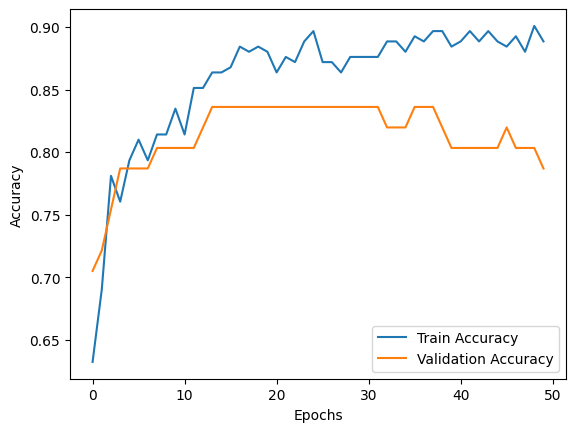

In [2]:
def build_model_dropout_02():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="relu")(all_features)
    x = layers.Dropout(0.2)(x)  
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model_dropout_02()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

-------------
# Example 2 with a dropout rate of 0.5

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6699 - loss: 0.6476 - val_accuracy: 0.8197 - val_loss: 0.5843
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7147 - loss: 0.6087 - val_accuracy: 0.8197 - val_loss: 0.5477
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6785 - loss: 0.6024 - val_accuracy: 0.8033 - val_loss: 0.5213
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7489 - loss: 0.5646 - val_accuracy: 0.8197 - val_loss: 0.4964
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8066 - loss: 0.5083 - val_accuracy: 0.8361 - val_loss: 0.4739
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8296 - loss: 0.4936 - val_accuracy: 0.8361 - val_loss: 0.4556
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7849 - loss: 0.5010 - val_accuracy: 0.8361 - val_loss: 0.4402
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8079 - loss: 0.4759 - val_accuracy: 0.8361 - val_loss: 0.4273
Epoch 9

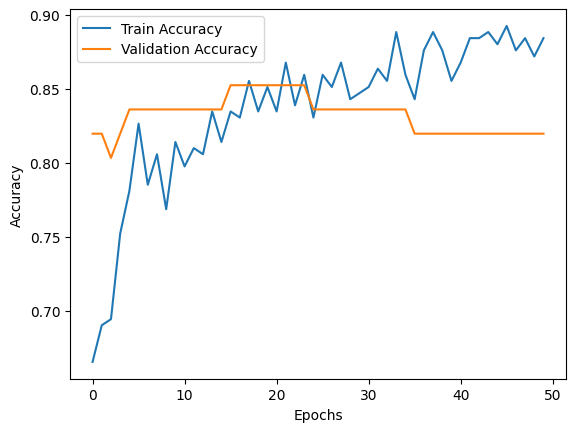

In [3]:
def build_model_dropout_05():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="relu")(all_features)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = build_model_dropout_05()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

------------
# Example 3 with a dropout rate of 0.7

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5352 - loss: 0.7758 - val_accuracy: 0.7049 - val_loss: 0.6156
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5743 - loss: 0.7526 - val_accuracy: 0.8033 - val_loss: 0.5788
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6350 - loss: 0.6416 - val_accuracy: 0.7705 - val_loss: 0.5490
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6823 - loss: 0.6480 - val_accuracy: 0.8197 - val_loss: 0.5250
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6685 - loss: 0.6658 - val_accuracy: 0.8361 - val_loss: 0.5059
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7123 - loss: 0.5956 - val_accuracy: 0.8525 - val_loss: 0.4896
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6601 - loss: 0.6413 - val_accuracy: 0.8361 - val_loss: 0.4747
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7469 - loss: 0.5619 - val_accuracy: 0.8361 - val_loss: 0.4621
Epoch 9

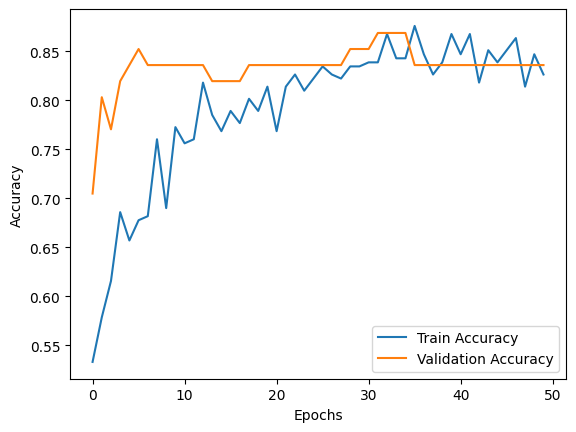

In [5]:
def build_model_dropout_07():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="relu")(all_features)
    x = layers.Dropout(0.7)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = build_model_dropout_07()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()